In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, log_loss, brier_score_loss
)
from load_data import load_modality_data
from modality_eval import evaluate_modality
from augmented_modality_eval import aug_evaluate_modality
import numpy as np
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, 
                           matthews_corrcoef, confusion_matrix)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from diagnostics import plot_diagnostics

In [2]:
base_dir = 'h5_freq'
subjects = [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28]

## Baseline

In [3]:
font = '1F'
condition = 'Par' #put 'Parity' for parity, 'Control' for control

### Cross-modality

#### Digits → Number Words

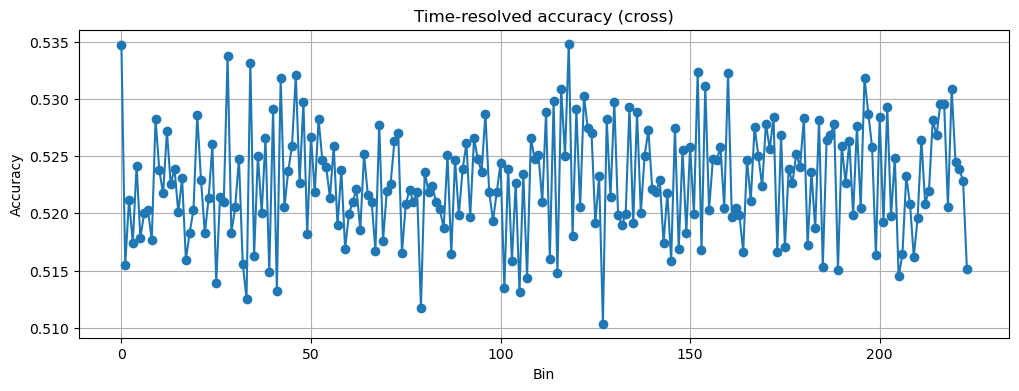

In [4]:
dig_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'cross', 'NumWo')

#### Number Words → Digits

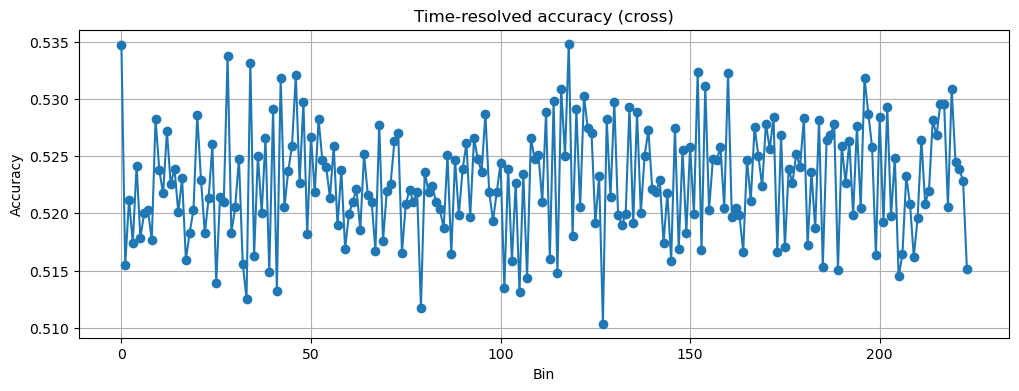

In [5]:
words_to_dig = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'cross', 'Dig')

#### Plotting diagnostics


Digits→Words, same condition, same font Performance:
Accuracy: 0.523 (Chance: 0.5)
Balanced Accuracy: 0.523
ROC AUC: 0.536
Matthews CC: 0.045
Support: 224 bins


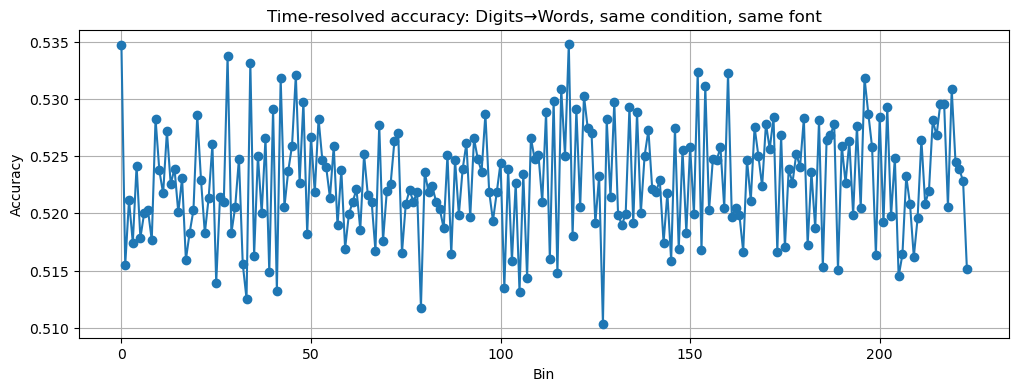


Top 5 Feature Importances:
   feature  importance
9        9    0.102647
7        7    0.102582
5        5    0.102571
2        2    0.102210
0        0    0.101242

Words→Digits, same condition, same font Performance:
Accuracy: 0.523 (Chance: 0.5)
Balanced Accuracy: 0.523
ROC AUC: 0.536
Matthews CC: 0.045
Support: 224 bins


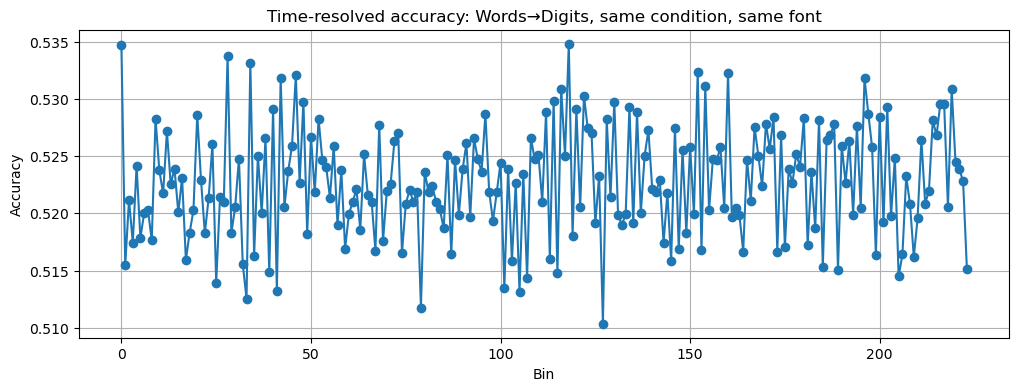


Top 5 Feature Importances:
   feature  importance
9        9    0.102647
7        7    0.102582
5        5    0.102571
2        2    0.102210
0        0    0.101242


In [6]:
for name, result in [
    ('Digits→Words, same condition, same font', dig_to_words),
    ('Words→Digits, same condition, same font', words_to_dig)
]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc = result['time_resolved']
            plt.figure(figsize=(12,4))
            plt.plot(bin_acc[:,0], bin_acc[:,1], marker='o')
            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

### Within-modality

#### Digits

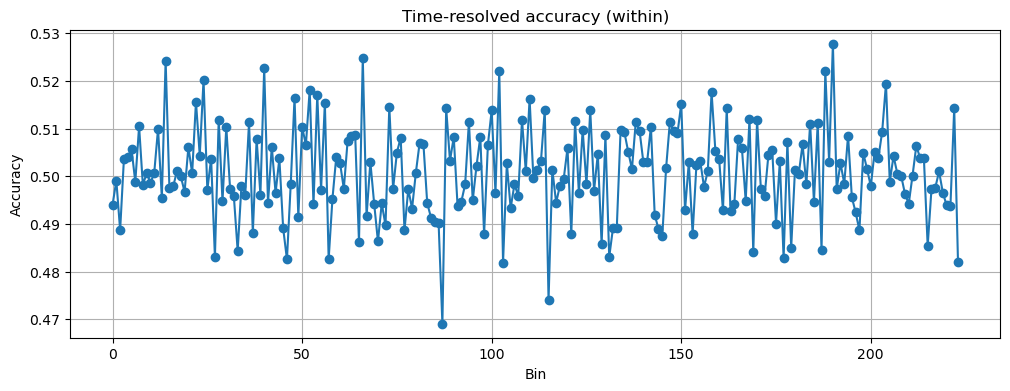

In [7]:
dig_results = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'within')

#### Number Words (Within Modality)

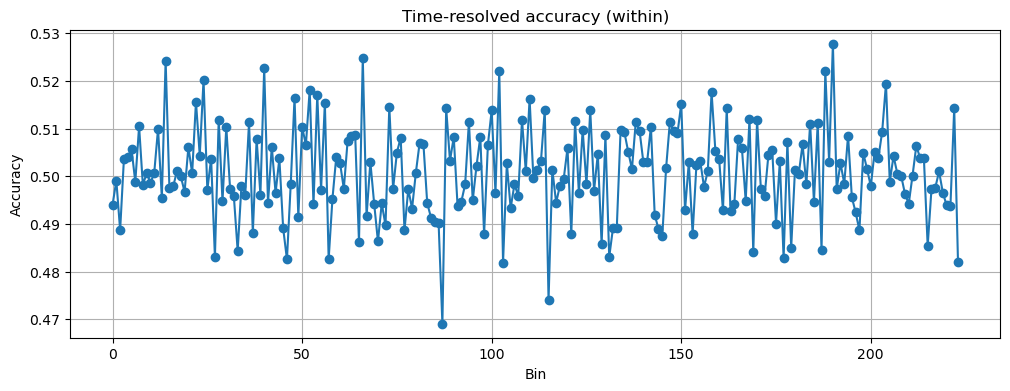

In [8]:
numwo_results = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'within')

#### Plotting diagnostics


Digits→Digits, same condition, same font Performance:
Accuracy: 0.501 (Chance: 0.5)
Balanced Accuracy: 0.501
ROC AUC: 0.501
Matthews CC: 0.002
Support: 224 bins


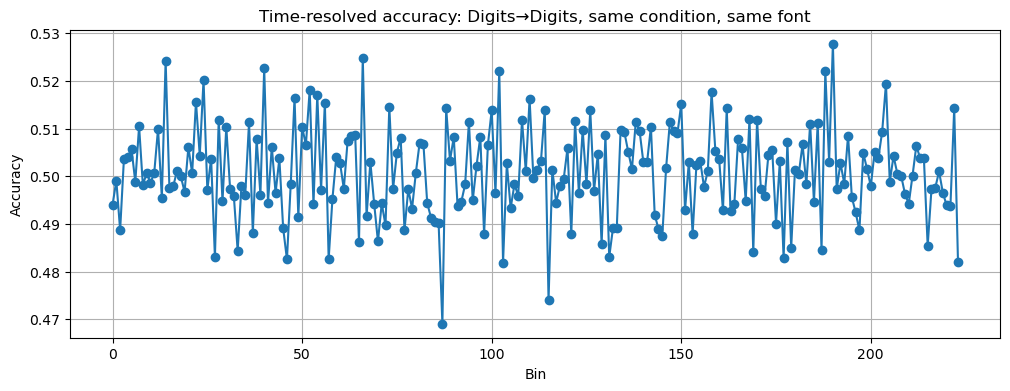


Top 5 Feature Importances:
   feature  importance
5        5    0.104382
9        9    0.104137
0        0    0.103633
1        1    0.102476
2        2    0.101307

Words→Words, same condition, same font Performance:
Accuracy: 0.501 (Chance: 0.5)
Balanced Accuracy: 0.501
ROC AUC: 0.501
Matthews CC: 0.002
Support: 224 bins


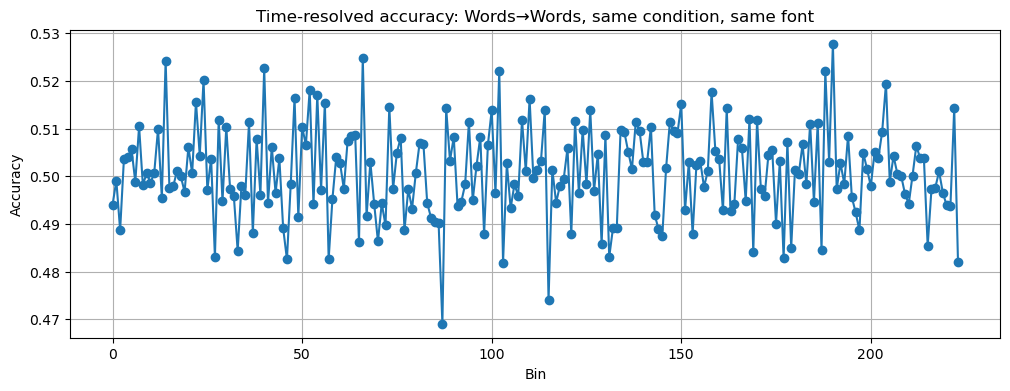


Top 5 Feature Importances:
   feature  importance
5        5    0.104382
9        9    0.104137
0        0    0.103633
1        1    0.102476
2        2    0.101307


In [9]:
for name, result in [
    ('Digits→Digits, same condition, same font', dig_results),
    ('Words→Words, same condition, same font', numwo_results)
]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc = result['time_resolved']
            plt.figure(figsize=(12,4))
            plt.plot(bin_acc[:,0], bin_acc[:,1], marker='o')
            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

### Mixed modality

#### Mixed → Digits

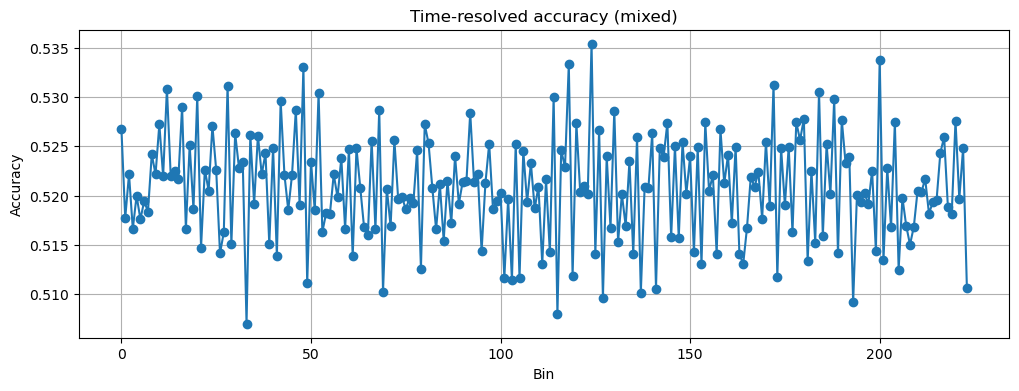

In [10]:
mixed_to_digits = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'Dig')

#### Mixed → Number Words

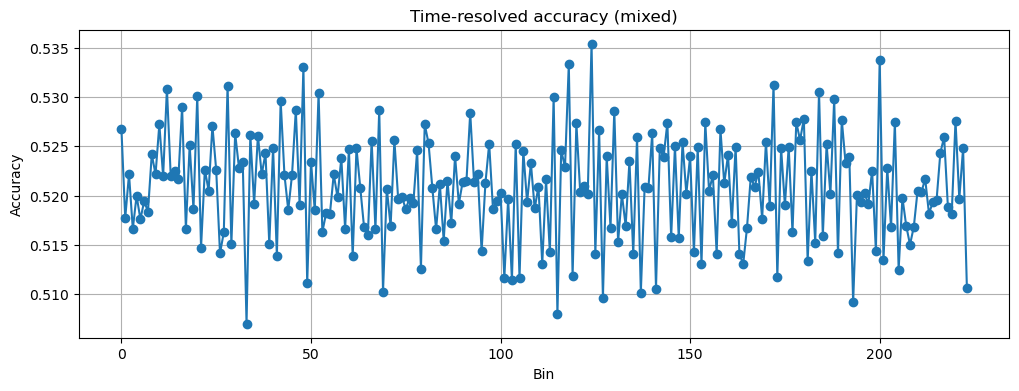

In [11]:
mixed_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'NumWo')

#### Plotting diagnostics


Mixed→Digits, same condition, same font Performance:
Accuracy: 0.521 (Chance: 0.5)
Balanced Accuracy: 0.521
ROC AUC: 0.533
Matthews CC: 0.042
Support: 224 bins


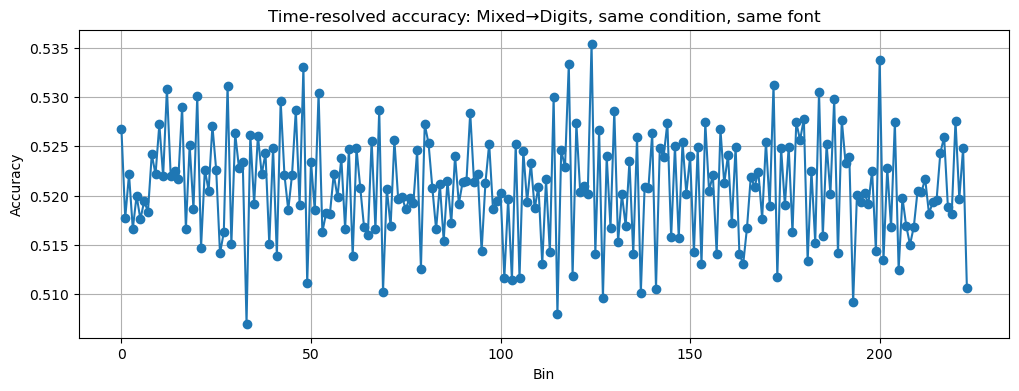


Top 5 Feature Importances:
   feature  importance
0        0    0.106023
2        2    0.103929
5        5    0.103145
1        1    0.101975
3        3    0.101942

Mixed→Words, same condition, same font Performance:
Accuracy: 0.521 (Chance: 0.5)
Balanced Accuracy: 0.521
ROC AUC: 0.533
Matthews CC: 0.042
Support: 224 bins


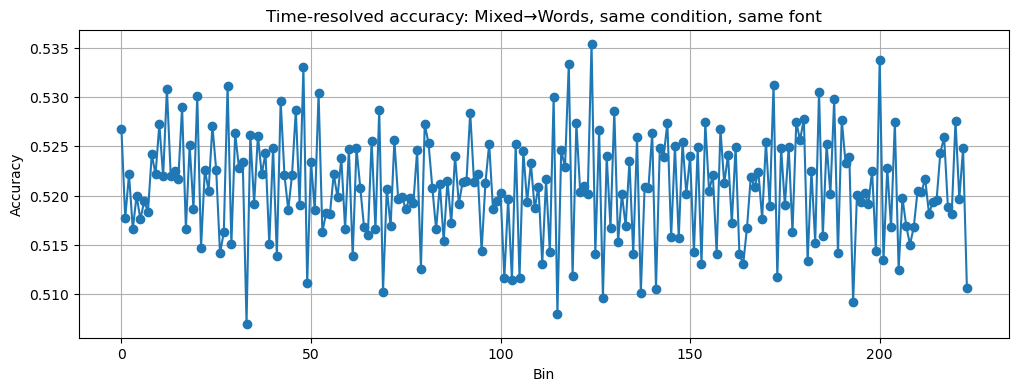


Top 5 Feature Importances:
   feature  importance
0        0    0.106023
2        2    0.103929
5        5    0.103145
1        1    0.101975
3        3    0.101942


In [12]:
for name, result in [('Mixed→Digits, same condition, same font', mixed_to_digits), 
                    ('Mixed→Words, same condition, same font', mixed_to_words)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc = result['time_resolved']
            plt.figure(figsize=(12,4))
            plt.plot(bin_acc[:,0], bin_acc[:,1], marker='o')
            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

## Augmented

In [3]:
modality = 'Dig'
mode = 'within'
test_mod=None #put None for within

### Font separation

In [4]:
condition = 'Par'

In [ ]:
f1_20s = aug_evaluate_modality(base_dir, subjects, modality, 
                     '1F', '20F/S', 
                     condition, mode=mode, test_mod=test_mod)

f1_20a = aug_evaluate_modality(base_dir, subjects, modality, 
                     '1F', '20F/A', 
                     condition, mode=mode, test_mod=test_mod)

f20a_20s = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/A', '20F/S', 
                     condition, mode=mode, test_mod=test_mod)

f20s_20a = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/S', '20F/A', 
                     condition, mode=mode, test_mod=test_mod)

f20a_1f = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/A', '1F', 
                     condition, mode=mode, test_mod=test_mod)

f20s_1f = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/S', '1F', 
                     condition, mode=mode, test_mod=test_mod)

In [ ]:
for name, result in [(f'1F → 20F (S) across {modality}, {condition}, {mode}', f1_20s),
                     (f'1F → 20F (A) across {modality}, {condition}, {mode}', f1_20a),
                     (f'20F (A) → 20F (S) across {modality}, {condition}, {mode}', f20a_20s),
                     (f'20F (S) → 20F (A) across {modality}, {condition}, {mode}', f20s_20a),
                     (f'20F (A) → 1F across {modality}, {condition}, {mode}', f20a_1f),
                     (f'20F (S) → 1F across {modality}, {condition}, {mode}', f20s_1f)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc = result['time_resolved']
            plt.figure(figsize=(12,4))
            plt.plot(bin_acc[:,0], bin_acc[:,1], marker='o')
            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

### Condition separation

In [ ]:
font = '20F/A'

In [ ]:
par_c1 = aug_evaluate_modality(base_dir, subjects, modality, 
                     font, condition_train='Parity', condition_test='Control',
                     mode=mode, test_mod=test_mod)

c1_par = aug_evaluate_modality(base_dir, subjects, modality, 
                     font, condition_train='Control', condition_test='Parity',
                     mode=mode, test_mod=test_mod)

In [ ]:
for name, result in [(f'Parity → Control across {modality}, {font}, {mode}', par_c1),
                     (f'Control → Parity across {modality}, {font}, {mode}', c1_par)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {len(result.get('time_resolved', []))} bins" if 'time_resolved' in result else f"Support: {result.get('support', 'N/A')} samples")
        
        if 'time_resolved' in result:
            bin_acc = result['time_resolved']
            plt.figure(figsize=(12,4))
            plt.plot(bin_acc[:,0], bin_acc[:,1], marker='o')
            plt.xlabel('Bin')
            plt.ylabel('Accuracy')
            plt.title(f'Time-resolved accuracy: {name}')
            plt.grid(True)
            plt.show()
        
        if 'feature_importances' in result:
            print("\nTop 5 Feature Importances:")
            print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")